In [1]:
# import required libraries
import pandas as pd  # handles dataframes
import matplotlib.pyplot as plt # data visualization
# apply Holt-Winters Exponential Smoothing method for time series prediction
from statsmodels.tsa.holtwinters import ExponentialSmoothing  
from sklearn.metrics import mean_squared_error # evaluate the accuracy of the model
import numpy as np # used for mathematical operations

In [2]:
# remove future warnings that don't affect how current code runs
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# loads the dataset
df = pd.read_csv("us_retail_sales.csv")

# display the first five rows of the dataset
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,146925,147223,146805,148032,149010,149800,150761.0,151067.0,152588.0,153521.0,153583.0,155614.0
1,1993,157555,156266,154752,158979,160605,160127,162816.0,162506.0,163258.0,164685.0,166594.0,168161.0
2,1994,167518,169649,172766,173106,172329,174241,174781.0,177295.0,178787.0,180561.0,180703.0,181524.0
3,1995,182413,179488,181013,181686,183536,186081,185431.0,186806.0,187366.0,186565.0,189055.0,190774.0
4,1996,189135,192266,194029,194744,196205,196136,196187.0,196218.0,198859.0,200509.0,200174.0,201284.0


In [4]:
# display basic information and check for missing values
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    30 non-null     int64  
 1   JAN     30 non-null     int64  
 2   FEB     30 non-null     int64  
 3   MAR     30 non-null     int64  
 4   APR     30 non-null     int64  
 5   MAY     30 non-null     int64  
 6   JUN     30 non-null     int64  
 7   JUL     29 non-null     float64
 8   AUG     29 non-null     float64
 9   SEP     29 non-null     float64
 10  OCT     29 non-null     float64
 11  NOV     29 non-null     float64
 12  DEC     29 non-null     float64
dtypes: float64(6), int64(7)
memory usage: 3.2 KB


(None,
 YEAR    0
 JAN     0
 FEB     0
 MAR     0
 APR     0
 MAY     0
 JUN     0
 JUL     1
 AUG     1
 SEP     1
 OCT     1
 NOV     1
 DEC     1
 dtype: int64)

In [5]:
# reshape the data to format so a time series analysis can be run
df_melted = df.melt(id_vars=["YEAR"], var_name="MONTH", value_name="SALES")
df_melted["DATE"] = pd.to_datetime(df_melted["YEAR"].astype(str) + "-" + df_melted["MONTH"], format="%Y-%b")
# creates a new column called DATE that combines MONTH and YEAR into 'YEAR-MM-DD' format
df_melted = df_melted.sort_values("DATE")  

# display the first five rows of the updated dataset
df_melted.head()

,YEAR,MONTH,SALES,DATE
0,1992,JAN,146925.0,1992-01-01
30,1992,FEB,147223.0,1992-02-01
60,1992,MAR,146805.0,1992-03-01
90,1992,APR,148032.0,1992-04-01
120,1992,MAY,149010.0,1992-05-01


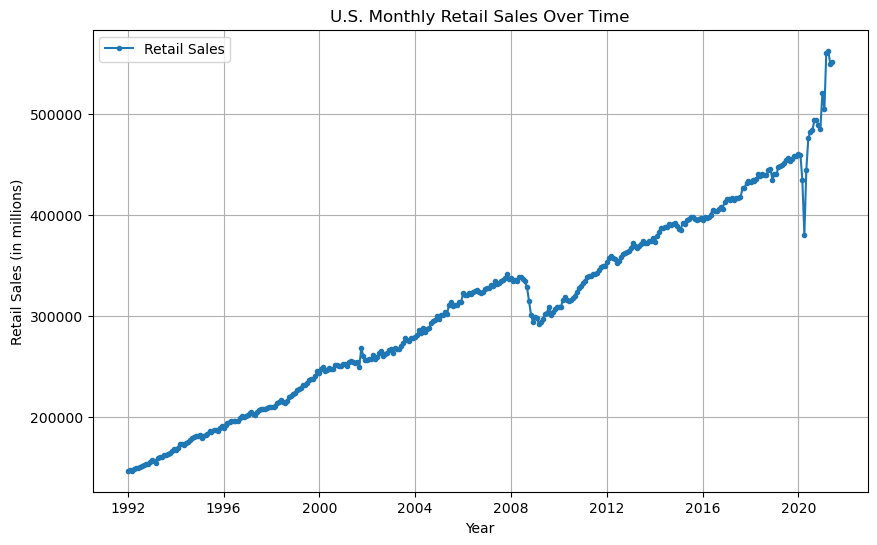

In [6]:
# use matplotlib to plot the data
plt.figure(figsize=(10, 6))
plt.plot(df_melted["DATE"], df_melted["SALES"], marker="o", linestyle="-", markersize=3, label="Retail Sales")
plt.xlabel("Year")
plt.ylabel("Retail Sales (in millions)")
plt.title("U.S. Monthly Retail Sales Over Time")
plt.legend()
plt.grid(True)
plt.show()

### Observations: 
- Upward trend that shows sales increasing over time
-  Steep dip in 2020 could be attributed to COVID, which affected sales globally
-  Another steep dip in 2009 may be related to the finacal crisis in 2008
-  Other smaller fluctuations may be seasonal 

In [7]:
# Convert 'DATE' column to pandas datetime format to allow time series analysis
df_melted['DATE'] = pd.to_datetime(df_melted['DATE'])

# display the first five rows of the updated dataset
df_melted.head()

,YEAR,MONTH,SALES,DATE
0,1992,JAN,146925.0,1992-01-01
30,1992,FEB,147223.0,1992-02-01
60,1992,MAR,146805.0,1992-03-01
90,1992,APR,148032.0,1992-04-01
120,1992,MAY,149010.0,1992-05-01


### 2.Split this data into a training and test set. Use the last year of data (July 2020 – June 2021) of <br>data as your test set and the rest as your training set.

In [8]:
# split data into training and test sets based on specific time frames
# train all data before one year test time frame
train = df_melted[df_melted['DATE'] < "2020-07-01"]  
# allows for one full year of testing
test = df_melted[(df_melted['DATE'] >= "2020-07-01") & (df_melted['DATE'] <= "2021-06-01")] 

print(train.head())
print(test.head())

     YEAR MONTH     SALES       DATE
0    1992   JAN  146925.0 1992-01-01
30   1992   FEB  147223.0 1992-02-01
60   1992   MAR  146805.0 1992-03-01
90   1992   APR  148032.0 1992-04-01
120  1992   MAY  149010.0 1992-05-01
     YEAR MONTH     SALES       DATE
208  2020   JUL  481627.0 2020-07-01
238  2020   AUG  483716.0 2020-08-01
268  2020   SEP  493327.0 2020-09-01
298  2020   OCT  493991.0 2020-10-01
328  2020   NOV  488652.0 2020-11-01


In [9]:
# Set the 'DATE' column as the index (first column) (required for time series)
train.set_index('DATE', inplace=True)  # inplace=True: changes made to train dataset,not original df
test.set_index('DATE', inplace=True)   # inplace=True: changes made to test dataset,not original df

# Verify the indexes
print(train.head())
print(test.head())

            YEAR MONTH     SALES
DATE                            
1992-01-01  1992   JAN  146925.0
1992-02-01  1992   FEB  147223.0
1992-03-01  1992   MAR  146805.0
1992-04-01  1992   APR  148032.0
1992-05-01  1992   MAY  149010.0
            YEAR MONTH     SALES
DATE                            
2020-07-01  2020   JUL  481627.0
2020-08-01  2020   AUG  483716.0
2020-09-01  2020   SEP  493327.0
2020-10-01  2020   OCT  493991.0
2020-11-01  2020   NOV  488652.0


In [10]:
# display the size of the training and test sets
print(len(train), len(test))

342 12


### 3. Use the training set to build a predictive model for the monthly retail sales.

In [11]:
# Using ExponentialSmoothing model as SARIMA kept erroring
# set frequency of the training data to monthly
train = train.asfreq('MS')

# fit the model with additive trend and seasonal components
model = ExponentialSmoothing(train["SALES"], trend="add", seasonal="add", seasonal_periods=12)
fitted_model = model.fit()

# print fitted model summary
print(fitted_model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    SALES   No. Observations:                  342
Model:             ExponentialSmoothing   SSE                    11800950141.002
Optimized:                         True   AIC                           5967.969
Trend:                         Additive   BIC                           6029.326
Seasonal:                      Additive   AICC                          5970.087
Seasonal Periods:                    12   Date:                 Sun, 02 Feb 2025
Box-Cox:                          False   Time:                         23:28:24
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.9242857                alpha                 True
smoothing_trend          

C:\Users\maure\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


### 4. Use the model to predict the monthly retail sales on the last year of data

In [12]:
# Use the model to predict the test set
test_predictions = fitted_model.forecast(len(test))

# print the test predictions
print(test_predictions)

2020-07-01    474567.565026
2020-08-01    475414.392468
2020-09-01    476022.831549
2020-10-01    477202.575306
2020-11-01    478050.117973
2020-12-01    479028.123668
2021-01-01    479926.908189
2021-02-01    480303.309751
2021-03-01    480722.116062
2021-04-01    481051.890431
2021-05-01    484572.109312
2021-06-01    484359.670539
Freq: MS, dtype: float64


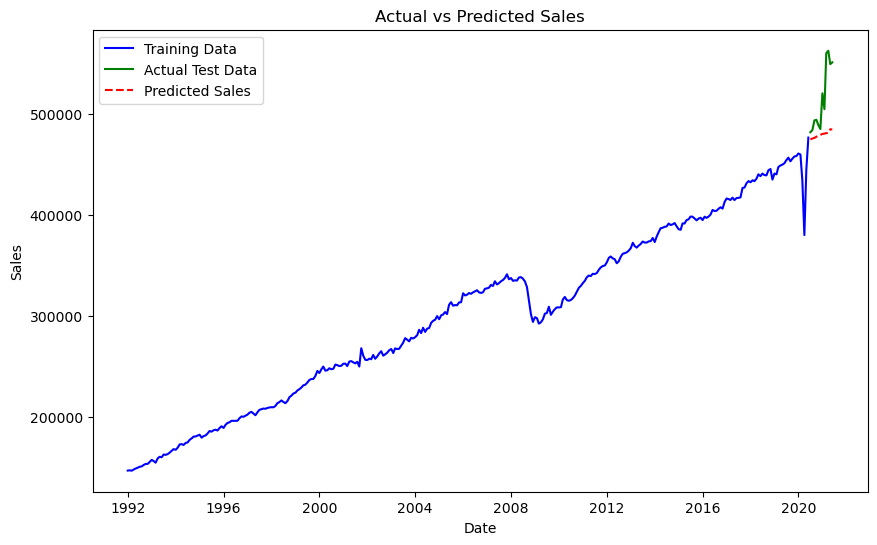

In [13]:
# plot the data including the prediction using the DATE index of the DataFrame
plt.figure(figsize=(10, 6))
plt.plot(train.index, train["SALES"], label="Training Data", color="blue")
plt.plot(test.index, test["SALES"], label="Actual Test Data", color="green")
plt.plot(test.index, test_predictions, label="Predicted Sales", color="red", linestyle="dashed")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

### 5. Report the RMSE of the model predictions on the test set

In [15]:
# calculate RMSE to evaluate the model 45156 out of 100,000s is an acceptable error
rmse = np.sqrt(mean_squared_error(test["SALES"], test_predictions))
print(f"RMSE: {rmse}")

RMSE: 45156.971718586414
